<a href="https://colab.research.google.com/github/hiba2026-cloud/Northstar-Analytics/blob/main/notebooks/NorthStar_MongoDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# HIBA ABDUL SALAM
# 33126931

In [ ]:
install.packages("tidyverse")
install.packages("sqldf")

library(readr)
library(dplyr)
library(ggplot2)
library(sqldf)

base_url <- "https://raw.githubusercontent.com/hiba2026-cloud/Northstar-Analytics/main/"

orders      <- read_csv(paste0(base_url, "orders.csv"))
deliveries  <- read_csv(paste0(base_url, "deliveries.csv"))
complaints  <- read_csv(paste0(base_url, "complaints.csv"))
customers   <- read_csv(paste0(base_url, "customers.csv"))
drivers     <- read_csv(paste0(base_url, "drivers.csv"))
vehicles    <- read_csv(paste0(base_url, "vehicles.csv"))
hubs        <- read_csv(paste0(base_url, "hubs.csv"))
incidents   <- read_csv(paste0(base_url, "incidents.csv"))
app_events  <- read_csv(paste0(base_url, "app_events.csv"))

head(orders)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite

Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): order_id, customer_id, service_type, pickup_zone, dropoff_zone, pr...
dbl  (3): promised_window_hours, order_value, special_handling_flag
dttm (1): order_created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or

order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


In [ ]:
colnames(orders)
colnames(deliveries)
colnames(complaints)
colnames(customers)

[1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"

[1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation_amount"

[1] "customer_id"          "age"                  "home_zone"           
[4] "customer_type"        "signup_date"          "loyalty_score"       
[7] "app_engagement_score" "preferred_channel"    "account_status"

In [ ]:
# Total orders by service type

query1 <- sqldf("
SELECT
    service_type,
    COUNT(order_id) AS total_orders,
    ROUND(AVG(order_value),2) AS avg_order_value
FROM orders
GROUP BY service_type
ORDER BY total_orders DESC
")

query1

service_type,total_orders,avg_order_value
<chr>,<int>,<dbl>
Passenger,341,96.07
Parcel,308,87.62
Retail,297,90.01
Business,165,92.25
Medical,139,87.14


In [ ]:
# Delivery status performance analysis

query2 <- sqldf("
SELECT
    delivery_status,
    COUNT(delivery_id) AS total_deliveries,
    ROUND(AVG(route_distance_km),2) AS avg_distance,
    ROUND(AVG(fuel_or_charge_cost),2) AS avg_cost
FROM deliveries
GROUP BY delivery_status
ORDER BY total_deliveries DESC
")

query2

delivery_status,total_deliveries,avg_distance,avg_cost
<chr>,<int>,<dbl>,<dbl>
OnTime,616,13.78,12.68
Delayed,202,14.67,13.14
Failed,132,13.37,13.15


In [ ]:
# Complaints linked with delivery status

query3 <- sqldf("
SELECT
    d.delivery_status,
    COUNT(c.complaint_id) AS total_complaints,
    ROUND(AVG(c.compensation_amount),2) AS avg_compensation
FROM complaints c
JOIN deliveries d
ON c.order_id = d.order_id
GROUP BY d.delivery_status
ORDER BY total_complaints DESC
")

query3

delivery_status,total_complaints,avg_compensation
<chr>,<int>,<dbl>
OnTime,149,19.18
Delayed,48,18.36
Failed,35,25.47


In [ ]:
# Driver manual route override analysis

query4 <- sqldf("
SELECT
    delivery_status,
    ROUND(AVG(manual_route_override_count),2) AS avg_route_overrides,
    ROUND(AVG(fuel_or_charge_cost),2) AS avg_cost
FROM deliveries
GROUP BY delivery_status
ORDER BY avg_route_overrides DESC
")

query4

delivery_status,avg_route_overrides,avg_cost
<chr>,<dbl>,<dbl>
Delayed,1.07,13.14
Failed,1.04,13.15
OnTime,0.92,12.68


In [ ]:
# Hub performance analysis

query5 <- sqldf("
SELECT
    h.hub_name,
    d.delivery_status,
    COUNT(d.delivery_id) AS total_deliveries,
    ROUND(AVG(d.fuel_or_charge_cost),2) AS avg_cost
FROM deliveries d
JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY h.hub_name, d.delivery_status
ORDER BY total_deliveries DESC
")

query5

hub_name,delivery_status,total_deliveries,avg_cost
<chr>,<chr>,<int>,<dbl>
North Exchange,OnTime,93,12.86
East Dock,OnTime,85,12.59
West Gate,OnTime,83,12.79
Midtown Relay,OnTime,80,11.40
Riverside Hub,OnTime,76,12.79
South Link,OnTime,70,12.45
Central Core,OnTime,67,13.59
Airport Hub,OnTime,62,13.14
West Gate,Delayed,28,14.66


In [ ]:
# Query 6 — Incident severity analysis

query6 <- sqldf("
SELECT
    severity,
    COUNT(incident_id) AS total_incidents,
    ROUND(AVG(resolved_hours),2) AS avg_resolution_hours
FROM incidents
GROUP BY severity
ORDER BY total_incidents DESC
")

query6

severity,total_incidents,avg_resolution_hours
<chr>,<int>,<dbl>
Medium,106,11.47
Low,79,13.58
High,68,11.15
Critical,27,11.44


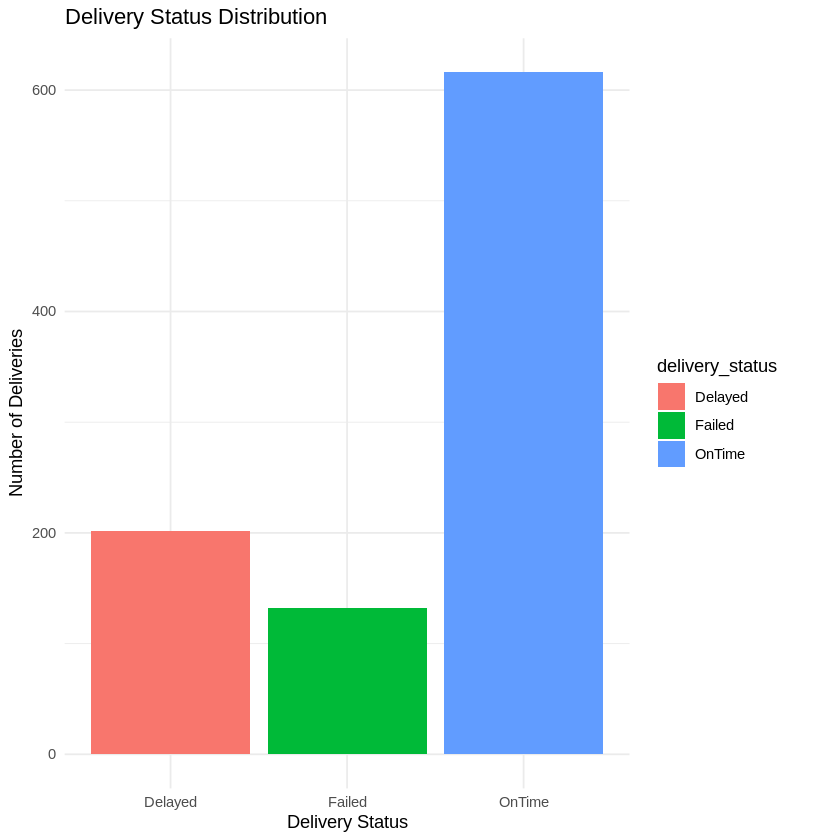

In [ ]:
# Delivery status bar chart

library(ggplot2)

ggplot(deliveries, aes(x = delivery_status, fill = delivery_status)) +
  geom_bar() +
  labs(
    title = "Delivery Status Distribution",
    x = "Delivery Status",
    y = "Number of Deliveries"
  ) +
  theme_minimal()

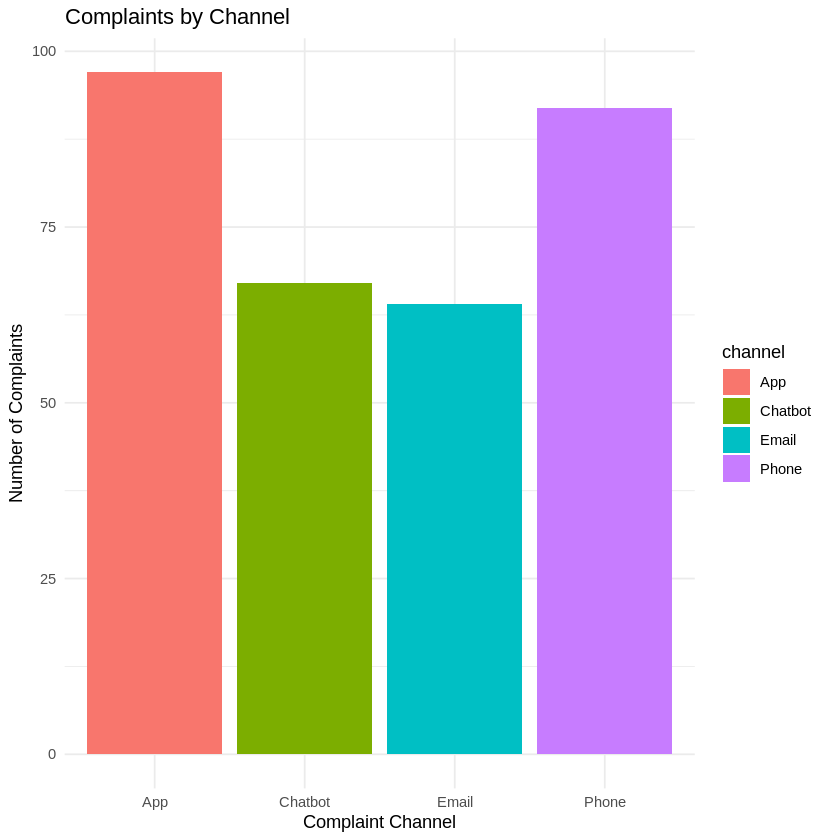

In [ ]:
ggplot(complaints,
       aes(x = channel,
           fill = channel)) +
geom_bar() +
labs(title = "Complaints by Channel",
     x = "Complaint Channel",
     y = "Number of Complaints") +
theme_minimal()

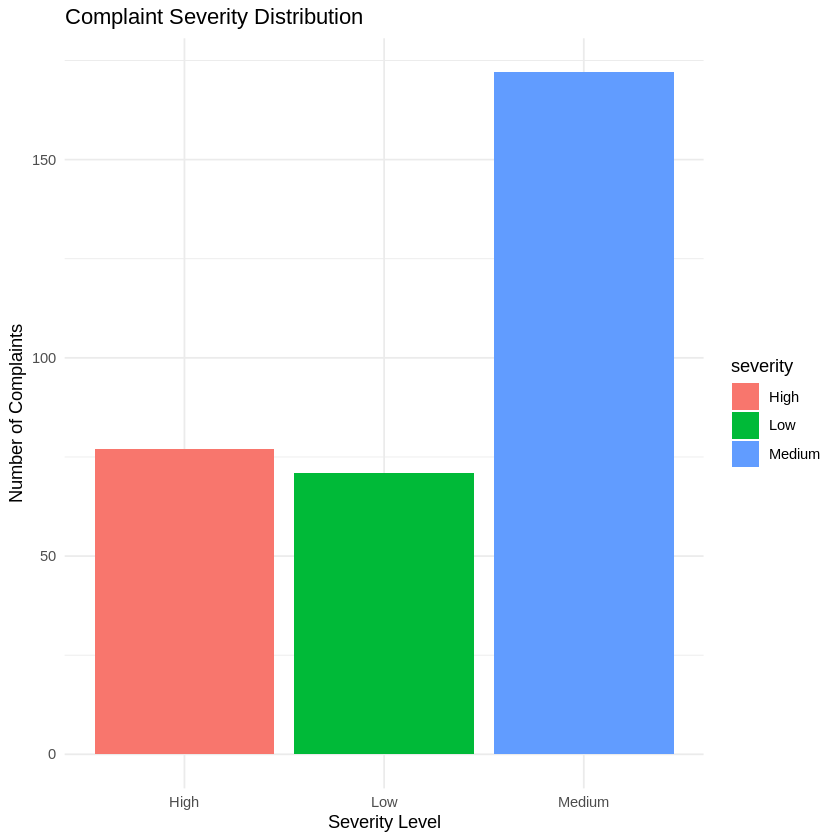

In [ ]:
# Complaint severity visualization

ggplot(complaints, aes(x = severity, fill = severity)) +
  geom_bar() +
  labs(
    title = "Complaint Severity Distribution",
    x = "Severity Level",
    y = "Number of Complaints"
  ) +
  theme_minimal()

In [ ]:
colnames(orders)
colnames(deliveries)
colnames(hubs)

[1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"

[1] "hub_id"         "hub_name"       "zone"           "hub_type"      
[5] "capacity_score"